In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

## Load and Process Fcirc Data

In [2]:
# Load fcirc data from CSV file with summary statistics
fcirc = pd.read_csv('data/fcirc.csv', sep='\t')

# Clean metabolite names (remove asterisks and convert to lowercase)
fcirc['Metabolite'] = fcirc['Metabolite'].str.replace('*', '').str.strip().str.lower()

# Filter for amino acids
amino_acids_list = ['alanine', 'arginine', 'asparagine', 'aspartate', 'glutamine', 
                    'glutamate', 'glycine', 'histidine', 'isoleucine', 'leucine',
                    'lysine', 'methionine', 'phenylalanine', 'proline', 'serine',
                    'threonine', 'tryptophan', 'tyrosine', 'valine']

fcirc_aa = fcirc[fcirc['Metabolite'].isin(amino_acids_list)]

# Display the data
print(f"Loaded {len(fcirc)} total metabolites with Fcirc measurements")
print(f"Found {len(fcirc_aa)} amino acids")
print(f"\nAmino acids in dataset:")
print(fcirc_aa[['Metabolite', 'MEAN', 'SEM', 'N']].to_string(index=False))

Loaded 33 total metabolites with Fcirc measurements
Found 19 amino acids

Amino acids in dataset:
   Metabolite  MEAN  SEM  N
    glutamine 37.89 1.16  4
      alanine 24.02 1.46  9
      glycine 13.79 0.54  4
       serine 11.31 0.21  4
       lysine 10.16 0.89  5
      leucine  9.93 0.64  9
       valine  9.89 0.32  5
   isoleucine  7.57 0.52  5
    threonine  6.02 0.45  7
     tyrosine  5.41 0.46  4
      proline  4.71 0.32  5
phenylalanine  4.27 0.33  7
   methionine  4.15 0.40  5
     arginine  4.11 0.22  5
    glutamate  3.95 0.39  4
   asparagine  2.94 0.29  5
    aspartate  2.38 0.42  5
   tryptophan  1.86 0.06  7
    histidine  1.77 0.17  5


/var/folders/n5/kq0k2frx06l30kyysqmgk1lw0000gn/T/ipykernel_64842/2636397580.py:5: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  fcirc['Metabolite'] = fcirc['Metabolite'].str.replace('*', '').str.strip().str.lower()


## Amino Acid Abundance Data

Load pre-calculated amino acid abundance data from proteome analysis and hydrolysate measurements.

In [3]:
from utils import get_amino_acid_names

# Load the proteome vs hydrolysate comparison
aa_comparison = pd.read_csv('./data/proteome_vs_hydrolysate_comparison.tsv', sep='\t', index_col=0)

# Create aa_freq_df from the comparison data for compatibility with downstream analysis
aa_names = get_amino_acid_names()
aa_name_to_code = {v: k for k, v in aa_names.items()}

aa_freq_df = aa_comparison.copy()
aa_freq_df = aa_freq_df.reset_index()
aa_freq_df = aa_freq_df.rename(columns={'index': 'Full Name', 'Hydrolysate Molar %': 'Frequency (%)'})
aa_freq_df['Amino Acid'] = aa_freq_df['Full Name'].map(aa_name_to_code)

print(f"Loaded amino acid abundance data:")
print(f"  Hydrolysate analysis: {len(aa_freq_df)} amino acids")
print(f"\nTop 10 most frequent amino acids in proteome:")
print(aa_freq_df[['Amino Acid', 'Full Name', 'Frequency (%)']].sort_values('Frequency (%)', ascending=False).head(10).to_string(index=False))

ModuleNotFoundError: No module named 'utils'

## Estimate Protein Degradation Fluxes

Use valine flux measurements to estimate total protein degradation, then calculate expected fluxes for all amino acids.

In [ ]:
# Protein degradation fluxes in fasted and fed mice (from valine measurements)
valine_freq = aa_freq_df[aa_freq_df['Amino Acid'] == 'V']['Frequency (%)'].values[0] / 100

valine_flux_fasted = 10.2  # nmol/g/min
valine_flux_fed = 6.2  # nmol/g/min

protein_degradation_flux_fasted = valine_flux_fasted / valine_freq
protein_degradation_flux_fed = valine_flux_fed / valine_freq

print(f"Estimated protein degradation flux in fasted mice: {protein_degradation_flux_fasted:.1f} nmol/g/min")
print(f"Estimated protein degradation flux in fed mice: {protein_degradation_flux_fed:.1f} nmol/g/min")

# Compute flux for each amino acid based on protein degradation flux
# Filter out rows with NaN in Full Name column
aa_freq_df_clean = aa_freq_df.dropna(subset=['Full Name'])
aa_freq_dict = dict(zip(aa_freq_df_clean['Full Name'], aa_freq_df_clean['Frequency (%)'] / 100))

# Create lowercase version for matching with fcirc data
protein_degradation_fluxes_fasted = {aa.lower(): protein_degradation_flux_fasted * freq for aa, freq in aa_freq_dict.items()}
protein_degradation_fluxes_fed = {aa.lower(): protein_degradation_flux_fed * freq for aa, freq in aa_freq_dict.items()}

Estimated protein degradation flux in fasted mice: 169.9 nmol/g/min
Estimated protein degradation flux in fed mice: 103.3 nmol/g/min


In [ ]:
# Estimate protein synthesis flux as equal to degradation flux in fasted state
valine_flux_fasted = 6.2  # nmol/g/min
protein_synthesis_flux_fasted = valine_flux_fasted / valine_freq
print(f"Estimated protein synthesis flux in fasted mice: {protein_synthesis_flux_fasted:.1f} nmol/g/min")

# Create a lowercase version for matching with fcirc data
protein_synthesis_fluxes_fasted = {aa.lower(): protein_synthesis_flux_fasted * freq for aa, freq in aa_freq_dict.items()}


Estimated protein synthesis flux in fasted mice: 103.3 nmol/g/min


## Calculate Mean Fcirc for Each Amino Acid

In [ ]:
# Debug: Check what keys are in each dataset
print("Keys in protein_degradation_fluxes_fasted:")
print(sorted(protein_degradation_fluxes_fasted.keys()))
print("\nUnique values in fcirc_aa['Metabolite']:")
print(sorted(fcirc_aa['Metabolite'].unique()))

Keys in protein_degradation_fluxes_fasted:
['alanine', 'arginine', 'asparagine', 'aspartate', 'cysteine', 'glutamate', 'glutamine', 'glycine', 'histidine', 'isoleucine', 'leucine', 'lysine', 'methionine', 'phenylalanine', 'proline', 'serine', 'threonine', 'tryptophan', 'tyrosine', 'valine']

Unique values in fcirc_aa['Metabolite']:
['alanine', 'arginine', 'asparagine', 'aspartate', 'glutamate', 'glutamine', 'glycine', 'histidine', 'isoleucine', 'leucine', 'lysine', 'methionine', 'phenylalanine', 'proline', 'serine', 'threonine', 'tryptophan', 'tyrosine', 'valine']


In [ ]:
# Create comparison dataframe from fcirc amino acid data
comparison_df = fcirc_aa.copy()
comparison_df = comparison_df.rename(columns={
    'Metabolite': 'Tracer',
    'MEAN': 'Mean Fcirc (nmol/min/g)',
    'SEM': 'SEM Fcirc (nmol/min/g)'
})

# Add protein degradation flux estimates
comparison_df['Protein Degradation Flux Fasted (nmol/min/g)'] = comparison_df['Tracer'].map(protein_degradation_fluxes_fasted)
comparison_df['Protein Degradation Flux Fed (nmol/min/g)'] = comparison_df['Tracer'].map(protein_degradation_fluxes_fed)

# Add protein synthesis flux estimates
comparison_df['Protein Syntesis Flux Fasted (nmol/min/g)'] = comparison_df['Tracer'].map(protein_synthesis_fluxes_fasted)

# Drop rows without protein degradation estimates (only check the flux columns)
comparison_df = comparison_df.dropna(subset=['Protein Degradation Flux Fasted (nmol/min/g)', 'Protein Degradation Flux Fed (nmol/min/g)'])

# Add essential vs non-essential classification
essential_amino_acids = ['histidine', 'isoleucine', 'leucine', 'lysine', 'methionine', 
                          'phenylalanine', 'threonine', 'tryptophan', 'valine', 'tyrosine']
comparison_df['Type'] = comparison_df['Tracer'].apply(lambda x: 'Essential' if x in essential_amino_acids else 'Non-essential')

print(f"\nAmino acids with both measured Fcirc and protein degradation estimates:")
print(comparison_df[['Tracer', 'Type', 'Mean Fcirc (nmol/min/g)', 'SEM Fcirc (nmol/min/g)', 'N']].to_string(index=False))


Amino acids with both measured Fcirc and protein degradation estimates:
       Tracer          Type  Mean Fcirc (nmol/min/g)  SEM Fcirc (nmol/min/g)  N
    glutamine Non-essential                    37.89                    1.16  4
      alanine Non-essential                    24.02                    1.46  9
      glycine Non-essential                    13.79                    0.54  4
       serine Non-essential                    11.31                    0.21  4
       lysine     Essential                    10.16                    0.89  5
      leucine     Essential                     9.93                    0.64  9
       valine     Essential                     9.89                    0.32  5
   isoleucine     Essential                     7.57                    0.52  5
    threonine     Essential                     6.02                    0.45  7
     tyrosine     Essential                     5.41                    0.46  4
      proline Non-essential                    

## Scatter Plot: Measured Fcirc vs Protein Degradation Flux

Compare measured amino acid circulating fluxes with predicted fluxes from protein degradation.

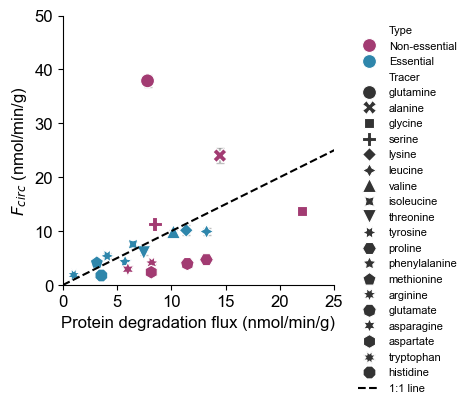

In [ ]:
# Create scatter plot comparing measured Fcirc vs estimated protein degradation flux for fasted mice
f = plt.figure(figsize=(3.5, 3.5))

# Add error bars first (behind points)
plt.errorbar(
    comparison_df['Protein Degradation Flux Fasted (nmol/min/g)'],
    comparison_df['Mean Fcirc (nmol/min/g)'],
    yerr=comparison_df['SEM Fcirc (nmol/min/g)'],
    fmt='none',
    ecolor='gray',
    alpha=0.5,
    capsize=3,
    zorder=0
)

# Add scatter points on top - color by essential/non-essential
sns.scatterplot(
    data=comparison_df,
    x='Protein Degradation Flux Fasted (nmol/min/g)',
    y='Mean Fcirc (nmol/min/g)',
    hue='Type',
    style='Tracer',
    markers=True,
    palette={'Essential': '#2E86AB', 'Non-essential': '#A23B72'},
    s=100,
    legend='full'
)

plt.plot([0, 75], [0, 75], 'k--', label='1:1 line')
plt.xlim(0, 25)
plt.ylim(0, 50)


plt.xlabel('Protein degradation flux (nmol/min/g)')
plt.ylabel('$F_{circ}$ (nmol/min/g)')

# Add legend outside plot with 2 columns
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, ncol=1, fontsize=8)  
sns.despine()
plt.savefig('./output/fcirc_vs_protein_degradation.svg', bbox_inches='tight')
plt.show()